In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
import pickle
import warnings
warnings.filterwarnings("ignore")
print("All libraries imported successfully!")

All libraries imported successfully!


In [9]:
data = pd.read_csv(r"C:\Users\Ainee\OneDrive\Desktop\TrafficVolumeProject\archive\Metro_Interstate_Traffic_Volume.csv")

print("First 5 rows:")
display(data.head())  # Notebook friendly

print("\nDataset Info:")
print(data.info())

print("\nMissing Values per Column:")
print(data.isnull().sum())

First 5 rows:


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     object 
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  object 
 6   weather_description  48204 non-null  object 
 7   date_time            48204 non-null  object 
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 3.3+ MB
None

Missing Values per Column:
holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0


In [18]:
print(data.columns)

Index(['holiday', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main',
       'traffic_volume', 'hour', 'day', 'month', 'day_of_week', 'is_weekend'],
      dtype='object')


In [22]:
# Fill missing holidays 
data['holiday'] = data['holiday'].fillna("None")

# create weekend flag 
if 'day_of_week' in data.columns:
    data['is_weekend'] = data['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

# Drop unnecessary column
# Drop unnecessary column safely
data.drop(['weather_description'], axis=1, inplace=True, errors='ignore')

print("Cleaned & Feature Engineered Dataset:")
display(data.head())

Cleaned & Feature Engineered Dataset:


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,traffic_volume,hour,day,month,day_of_week,is_weekend
0,7,288.28,0.0,0.0,40,1,5545,9,2,10,1,0
1,7,289.36,0.0,0.0,75,1,4516,10,2,10,1,0
2,7,289.58,0.0,0.0,90,1,4767,11,2,10,1,0
3,7,290.13,0.0,0.0,90,1,5026,12,2,10,1,0
4,7,291.14,0.0,0.0,75,1,4918,13,2,10,1,0


In [ ]:
le = LabelEncoder()

data['holiday'] = le.fit_transform(data['holiday'])
data['weather_main'] = le.fit_transform(data['weather_main'])

X = data.drop("traffic_volume", axis=1)
y = data["traffic_volume"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (38563, 11)
Test Shape: (9641, 11)


In [24]:

# Initialize models
lin_reg = LinearRegression()
Dtree = DecisionTreeRegressor()
Rand = RandomForestRegressor()
svr = SVR()
XGB = XGBRegressor(objective='reg:squarederror', eval_metric='rmse')

# Fit models
lin_reg.fit(X_train, y_train)
Dtree.fit(X_train, y_train)
Rand.fit(X_train, y_train)
svr.fit(X_train, y_train)
XGB.fit(X_train, y_train)

# Predictions on training set
p1 = lin_reg.predict(X_train)
p2 = Dtree.predict(X_train)
p3 = Rand.predict(X_train)
p4 = svr.predict(X_train)
p5 = XGB.predict(X_train)

print("R2 Score on Training Data:\n")
print("Linear Regression:", r2_score(y_train, p1))
print("Decision Tree:", r2_score(y_train, p2))
print("Random Forest:", r2_score(y_train, p3))
print("SVR:", r2_score(y_train, p4))
print("XGBoost:", r2_score(y_train, p5))

R2 Score on Training Data:

Linear Regression: 0.18742395493791864
Decision Tree: 1.0
Random Forest: 0.9950202599158389
SVR: 0.0066334022241235635
XGBoost: 0.9761314392089844



Test R2 Score (Random Forest): 0.9651593265461431
Mean Squared Error: 137743.074907354
Root Mean Squared Error: 371.1375417649823
Mean Absolute Error: 208.94576911108805


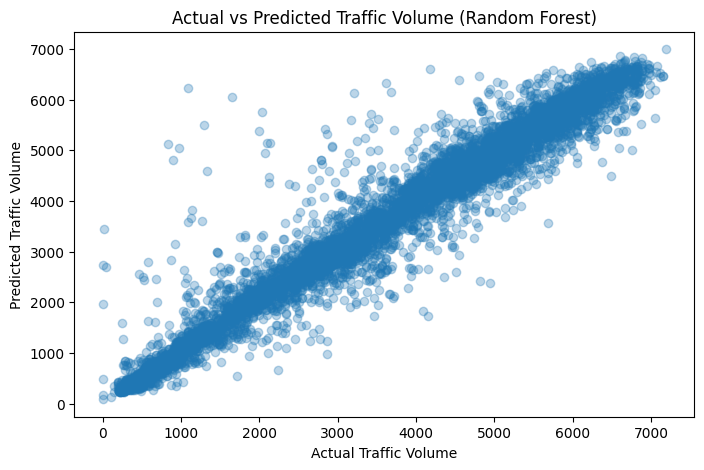

Model and encoder saved successfully!


In [25]:

# Test Predictions (Random Forest example)
p3_test = Rand.predict(X_test)

print("\nTest R2 Score (Random Forest):", r2_score(y_test, p3_test))

mse = mean_squared_error(y_test, p3_test)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, p3_test)

print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("Mean Absolute Error:", mae)

# Scatter Plot Actual vs Predicted
plt.figure(figsize=(8,5))
plt.scatter(y_test, p3_test, alpha=0.3)
plt.xlabel("Actual Traffic Volume")
plt.ylabel("Predicted Traffic Volume")
plt.title("Actual vs Predicted Traffic Volume (Random Forest)")
plt.show()

# Save Model
with open("model.pkl", "wb") as f:
    pickle.dump(Rand, f)

# Save Label Encoder
with open("encoder.pkl", "wb") as f:
    pickle.dump(le, f)

print("Model and encoder saved successfully!")